# Caral‑Supe Simulation

This notebook loads the configuration, runs the civilisation model, and compares the trajectory with archaeological population estimates from the fact database.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from src.db import get_connection
from src.evolution import run_simulation

%matplotlib inline

In [2]:
# Load simulation parameters
with open('../config/caral_params.yaml', 'r') as f:
    params = yaml.safe_load(f)

# Connect to the fact database (optional)
conn = get_connection('../caral_facts.sqlite')
# Fetch population observations for later comparison
pop_obs = pd.read_sql("SELECT * FROM observations WHERE type='population'", conn)

In [3]:
# Define climate stress based on config
def stress(step):
    return 1 if step in params['climate_stress_steps'] else 0

In [4]:
# Run simulation
trajectory = run_simulation(params, stress)
# Convert to DataFrame for plotting
df = pd.DataFrame(trajectory, columns=['step', 'P', 'M', 'E', 'rule', 'omega'])
df.head()

,step,P,M,E,rule,omega
0,0,2.276000,0.800000,0.0,1,CHAOTIC
1,1,2.586319,1.670400,0.0,1,CHAOTIC
2,2,2.934133,2.621408,0.0,1,CHAOTIC
3,3,3.322598,3.663990,0.0,1,CHAOTIC
4,4,3.754749,4.809830,0.0,1,CHAOTIC


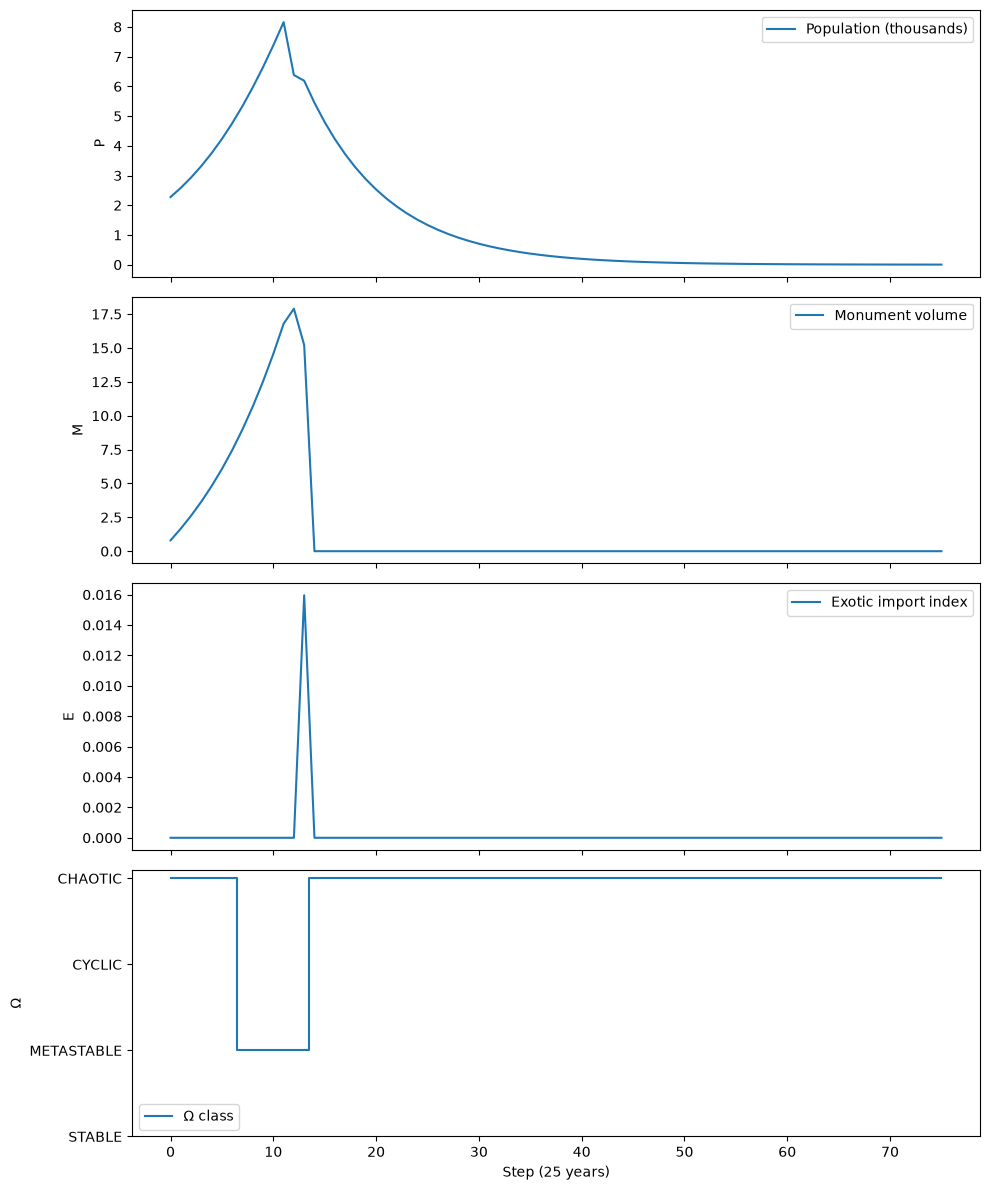

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

axes[0].plot(df['step'], df['P'], label='Population (thousands)')
axes[0].set_ylabel('P')
axes[0].legend()

axes[1].plot(df['step'], df['M'], label='Monument volume')
axes[1].set_ylabel('M')
axes[1].legend()

axes[2].plot(df['step'], df['E'], label='Exotic import index')
axes[2].set_ylabel('E')
axes[2].legend()

# Omega class as categorical steps
omega_map = {'STABLE': 0, 'METASTABLE': 1, 'CYCLIC': 2, 'CHAOTIC': 3}
omega_num = df['omega'].map(omega_map)
axes[3].step(df['step'], omega_num, where='mid', label='Ω class')
axes[3].set_yticks(list(omega_map.values()))
axes[3].set_yticklabels(list(omega_map.keys()))
axes[3].set_ylabel('Ω')
axes[3].set_xlabel('Step (25 years)')
axes[3].legend()

plt.tight_layout()
plt.show()

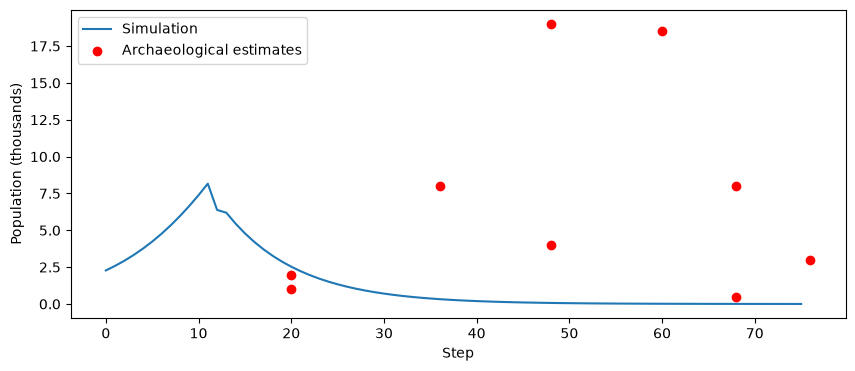

In [7]:
# Compare simulation with archaeological population observations
if not pop_obs.empty:
    # Convert observation years to approximate step numbers
    # Simulation start: step 0 corresponds to year -3500 (3500 BCE)
    pop_obs['year_mean'] = (pop_obs['year_from'] + pop_obs['year_to']) / 2
    pop_obs['step'] = ((pop_obs['year_mean'] + 3500) / params['simulation']['step_duration_years']).round().astype(int)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['step'], df['P'], label='Simulation')
    ax.scatter(pop_obs['step'], pop_obs['value'], color='red', zorder=5, label='Archaeological estimates')
    ax.set_xlabel('Step')
    ax.set_ylabel('Population (thousands)')
    ax.legend()
    plt.show()
else:
    print('No population observations found in database.')

In [8]:
conn.close()